In [1]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_path = "Data/"

X_train = np.load(data_path + 'X_train.npy')
Y_train = np.load(data_path + 'Y_train.npy')

X_val = np.load(data_path + 'X_val.npy')
Y_val = np.load(data_path + 'Y_val.npy')

X_test = np.load(data_path + 'X_test.npy')
Y_test = np.load(data_path + 'Y_test.npy')

print(f"Données chargées")
print(f"X_train shape: {X_train.shape}") 

Données chargées
X_train shape: (9998, 10, 32, 32, 2)


In [3]:
INPUT_SHAPE = (32,32,2)

def build_CNN_extractor(d_model=128):
    
    model = keras.Sequential()
    model.add(layers.Input(shape=INPUT_SHAPE))
    
    model.add(layers.Conv2D(32, (3, 3), activation="relu"))
    model.add(layers.BatchNormalization())
    
    model.add(layers.Conv2D(64, (3, 3), activation="relu"))
    model.add(layers.BatchNormalization())

    model.add(layers.Flatten())
    model.add(layers.Dense(d_model))

    return model

In [8]:
def nmse_loss(y_true, y_pred):
    mse = tf.reduce_sum(tf.square(y_true - y_pred), axis=[1,2,3])
    power = tf.reduce_sum(tf.square(y_true), axis=[1,2,3])
    return tf.reduce_mean(mse / (power + tf.keras.backend.epsilon()))
    

In [ ]:
"""
def build_full_model(seq_length=10, d_model=128):
    # 1. Input (Séquence de matrices CSI) 
    inputs = layers.Input(shape=(seq_length, 32, 32, 2))

    # On isole le dernier snapshot connu pour la connexion résiduelle 
    last_snapshot = inputs[:, -1, :, :, :]

    # 2. CNN Spatial (appliqué à chaque instant t) 
    cnn_block = build_CNN_extractor(d_model)
    x = layers.TimeDistributed(cnn_block)(inputs) 

    # 3. Positional Encoding
    positions = tf.range(start=0, limit=seq_length, delta=1)
    pos_encoding = layers.Embedding(input_dim=seq_length, output_dim=d_model)(positions)
    x = x + pos_encoding 

    # 4. Transformer (Multi-Head Attention) 
    attention_1 = layers.MultiHeadAttention(num_heads=4, key_dim=d_model)(x, x)
    x = layers.Add()([x, attention_1])
    x = layers.LayerNormalization()(x)

    # 5. Extraction du vecteur final et reconstruction du résidu
    # On prend le dernier vecteur de la séquence de sortie du Transformer
    x = layers.Lambda(lambda x: x[:, -1, :])(x) 
    
    x = layers.Dense(32 * 32 * 2)(x)
    residu = layers.Reshape((32, 32, 2))(x)

    # 6. SOMME FINALE : Dernier instant + Correction (Résidu) 
    outputs = layers.Add()([last_snapshot, residu])

    return models.Model(inputs, outputs)
"""

In [15]:
def build_full_model(seq_length=10, d_model=128):
    # Input 
    inputs = layers.Input(shape=(seq_length, 32, 32, 2))

    # CNN
    cnn_block = build_CNN_extractor(d_model)
    x = layers.TimeDistributed(cnn_block)(inputs)

    # Positional Encoding
    positions = tf.range(start=0, limit=seq_length, delta=1)
    pos_encoding = layers.Embedding(input_dim=seq_length, output_dim=d_model)(positions)
    x = x + pos_encoding

    # Transformer
    attention_output = layers.MultiHeadAttention(num_heads=4, key_dim=d_model)(x, x)
    
    x = layers.Add()([x, attention_output])
    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32 * 32 * 2)(x)
    outputs = layers.Reshape((32, 32, 2))(x)

    return models.Model(inputs, outputs)

In [ ]:

# Multihead a 8 têtes plus 2 couche d'attention
"""
def build_deep_transformer_model(seq_length=10, d_model=256): # d_model augmenté à 256
    inputs = layers.Input(shape=(seq_length, 32, 32, 2))
    last_snapshot = inputs[:, -1, :, :, :]

    # CNN puissant
    cnn_block = build_CNN_extractor(d_model)
    x = layers.TimeDistributed(cnn_block)(inputs)

    # Positional Encoding
    positions = tf.range(start=0, limit=seq_length, delta=1)
    x = x + layers.Embedding(input_dim=seq_length, output_dim=d_model)(positions)

    # --- BLOC 1 : Attention ---
    att1 = layers.MultiHeadAttention(num_heads=8, key_dim=d_model)(x, x)
    x = layers.Add()([x, att1])
    x = layers.LayerNormalization()(x)

    # --- BLOC 2 : Deuxième couche d'Attention (Profondeur) ---
    att2 = layers.MultiHeadAttention(num_heads=8, key_dim=d_model)(x, x)
    x = layers.Add()([x, att2])
    x = layers.LayerNormalization()(x)

    # Extraction du résidu
    x = layers.Lambda(lambda t: t[:, -1, :])(x)
    x = layers.Dense(32 * 32 * 2)(x)
    residu = layers.Reshape((32, 32, 2))(x)

    # Somme Résiduelle Globale
    outputs = layers.Add()([last_snapshot, residu])

    return models.Model(inputs, outputs)
"""

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',      
    patience=3,             
    restore_best_weights=True 
)

In [16]:
EPOCHS = 3
BATCH_SIZE = 32 

model = build_full_model(seq_length=10, d_model=128)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Un rate plus faible pour la NMSE
    loss=nmse_loss,
    metrics=['mae']
)

history = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    callbacks=[early_stop],
    shuffle=True # Mélanger les séquences pour éviter la mémorisation
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 198s 580ms/step - loss: 0.0833 - mae: 0.0668 - val_loss: 0.0036 - val_mae: 0.0245
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 179s 573ms/step - loss: 0.0036 - mae: 0.0243 - val_loss: 0.0036 - val_mae: 0.0244
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 184s 588ms/step - loss: 0.0036 - mae: 0.0242 - val_loss: 0.0036 - val_mae: 0.0243


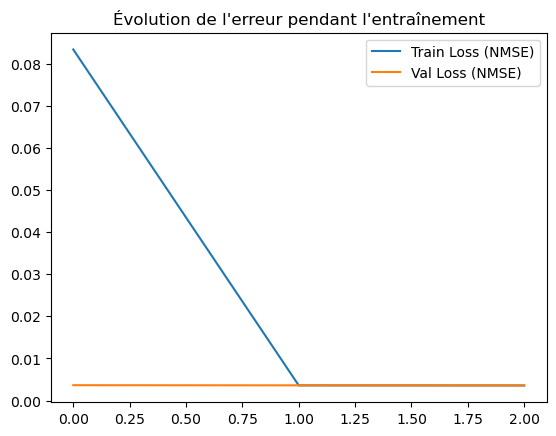

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss (NMSE)')
plt.plot(history.history['val_loss'], label='Val Loss (NMSE)')
plt.title('Évolution de l\'erreur pendant l\'entraînement')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


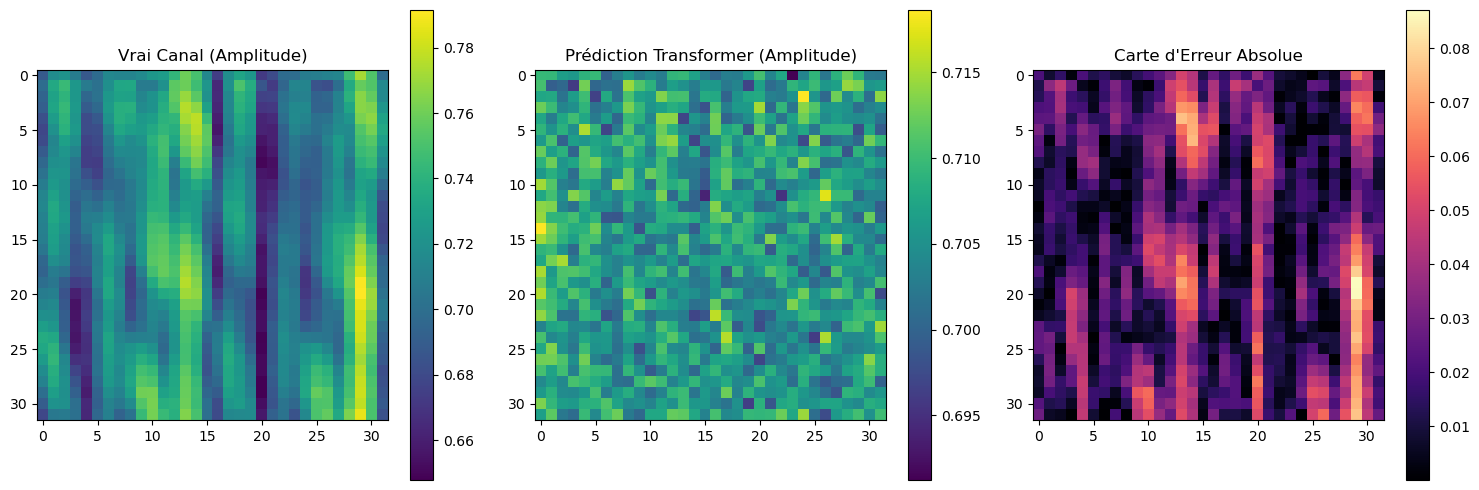

MAE Modèle : 0.02395
MAE Naïve (Persistance) : 0.03721
Amélioration : 35.63%


In [18]:
def visualize_prediction(model, X_test, Y_test, sample_idx=0):
    # 1. Prédire avec le modèle
    # X_test[sample_idx] a la forme (10, 32, 32, 2)
    input_seq = np.expand_dims(X_test[sample_idx], axis=0) 
    prediction = model.predict(input_seq)[0] # Forme (32, 32, 2)

    # 2. Baseline Naïve (Dernier instant de la séquence d'entrée)
    naive_baseline = X_test[sample_idx, -1, :, :, :]

    # 3. Calculer l'amplitude pour la visualisation (Partie Réelle^2 + Imaginaire^2)
    true_amp = np.sqrt(Y_test[sample_idx, ..., 0]**2 + Y_test[sample_idx, ..., 1]**2)
    pred_amp = np.sqrt(prediction[..., 0]**2 + prediction[..., 1]**2)
    error_map = np.abs(true_amp - pred_amp)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Vrai Canal (Amplitude)")
    plt.imshow(true_amp, cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title("Prédiction Transformer (Amplitude)")
    plt.imshow(pred_amp, cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Carte d'Erreur Absolue")
    plt.imshow(error_map, cmap='magma')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    mae_model = np.mean(np.abs(Y_test[sample_idx] - prediction))
    mae_naive = np.mean(np.abs(Y_test[sample_idx] - naive_baseline))
    
    print(f"MAE Modèle : {mae_model:.5f}")
    print(f"MAE Naïve (Persistance) : {mae_naive:.5f}")
    print(f"Amélioration : {((mae_naive - mae_model) / mae_naive)*100:.2f}%")

visualize_prediction(model, X_test, Y_test, sample_idx=42)

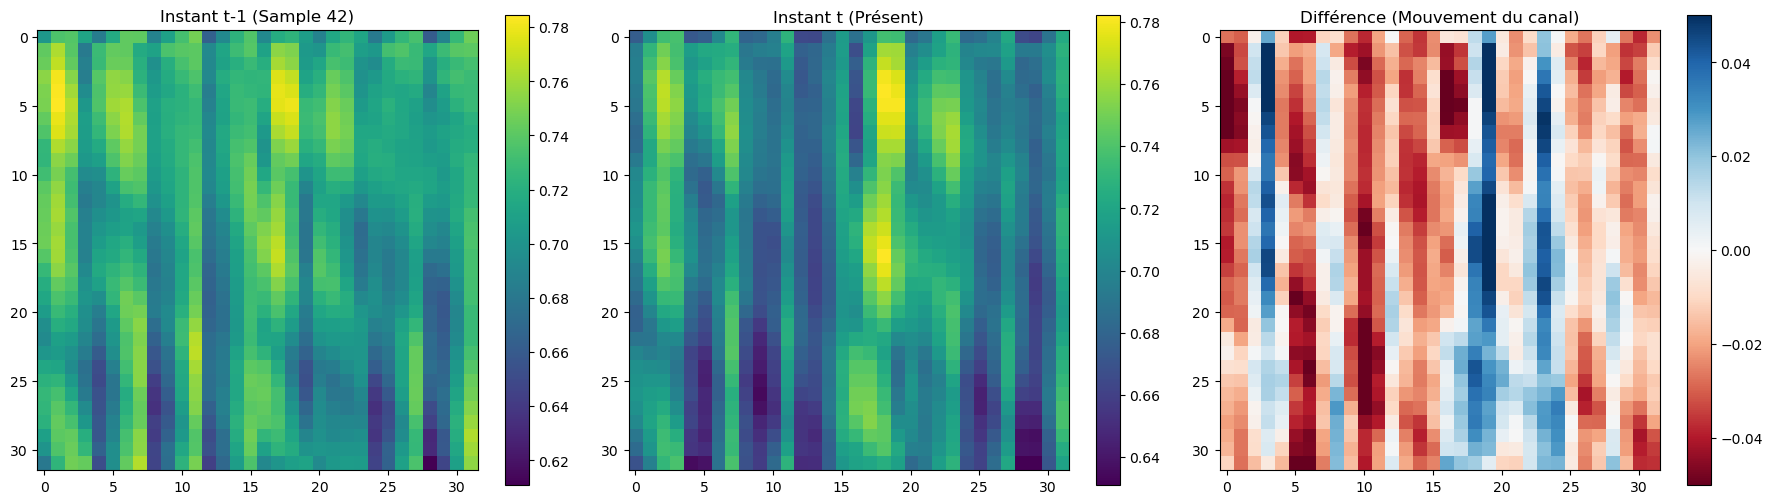

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_temporal_diff(X_test, sample_idx=42):
    # Extraire les deux derniers instants de la séquence d'entrée
    t_minus_1 = X_test[sample_idx, -2, :, :, :] # Instant t-1
    t_now = X_test[sample_idx, -1, :, :, :]     # Instant t 

    # Calculer l'amplitude pour la visualisation
    amp_t_minus_1 = np.sqrt(t_minus_1[..., 0]**2 + t_minus_1[..., 1]**2)
    amp_t_now = np.sqrt(t_now[..., 0]**2 + t_now[..., 1]**2)
    
    # Calculer la différence (le mouvement du canal)
    diff = amp_t_now - amp_t_minus_1

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.title(f"Instant t-1 (Sample {sample_idx})")
    plt.imshow(amp_t_minus_1, cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title(f"Instant t (Présent)")
    plt.imshow(amp_t_now, cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Différence (Mouvement du canal)")
    plt.imshow(diff, cmap='RdBu', vmin=-0.05, vmax=0.05) 
    plt.colorbar()

    plt.tight_layout()
    plt.show()

visualize_temporal_diff(X_test, sample_idx=42)